# 01 — CASIA-B Skeleton Extraction for GaitTR

This single notebook extracts 17-joint COCO skeletons from your CASIA-B raw videos and saves everything inside:

`/media/wadud/DriveUbuntu/GaitRecognition 2.0`

Raw input directory:

`/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/video`

Expected raw filename format:

`001-bg-01-000.avi`, `001-nm-06-090.avi`, `124-cl-02-180.avi`

Output structure:

```text
GaitRecognition 2.0/
├── data/
│   ├── index/casiab_video_index.csv
│   ├── poses/<pose_model_tag>/001/bg-01/000.npz
│   ├── reports/skeleton_extraction_summary.csv
│   └── splits/gallery_LT.csv, probe_LT_nm.csv, probe_LT_bg.csv, probe_LT_cl.csv
└── visuals/skeleton_debug/<pose_model_tag>/
```

Each `.npz` contains raw, filled, normalized, and normalized-filled keypoints. For later GaitTR training, use:

```python
keypoints_norm_filled
```

In [1]:
# ============================================================
# CELL 1 — Install missing packages only
# ============================================================

import sys
import subprocess
import importlib.util

def pip_install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name

    if importlib.util.find_spec(import_name) is None:
        print(f"[INSTALL] {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(f"[OK] {package_name} already installed")

# You said PyTorch is already set up, so this notebook does NOT install torch.
pip_install_if_missing("ultralytics", "ultralytics")
pip_install_if_missing("opencv-python", "cv2")
pip_install_if_missing("numpy", "numpy")
pip_install_if_missing("pandas", "pandas")
pip_install_if_missing("tqdm", "tqdm")
pip_install_if_missing("matplotlib", "matplotlib")

[OK] ultralytics already installed
[OK] opencv-python already installed
[OK] numpy already installed
[OK] pandas already installed
[OK] tqdm already installed
[OK] matplotlib already installed


In [2]:
# ============================================================
# CELL 2 — Imports, paths, and main configuration
# ============================================================

from pathlib import Path
import re
import time
import gc
import traceback
import warnings

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")

RAW_DIR = Path("/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/video")
EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")

# Recommended for RTX 3060 Laptop 6GB.
# If yolo26l-pose.pt is not available in your installed Ultralytics version,
# the notebook automatically tries YOLO11 fallback models.
POSE_MODEL_CANDIDATES = [
    "yolo26l-pose.pt",
    "yolo11l-pose.pt",
    "yolo26m-pose.pt",
    "yolo11m-pose.pt",
    "yolo26s-pose.pt",
    "yolo11s-pose.pt",
]

POSE_MODEL_NAME = POSE_MODEL_CANDIDATES[0]

DEVICE = 0 if torch.cuda.is_available() else "cpu"

IMG_SIZE = 640
DET_CONF = 0.25
IOU = 0.70
MAX_DET = 3

KP_CONF = 0.20
MIN_VALID_JOINTS = 8

TEST_FIRST_N = 5
RUN_FULL_EXTRACTION = True

SAVE_DEBUG_VIS_N = 100
VIS_STRIDE = 10

OVERWRITE = False
USE_HALF = True

def safe_model_tag(model_name: str) -> str:
    return Path(model_name).stem.replace("-", "_").replace(".", "_").replace(" ", "_")

MODEL_TAG = safe_model_tag(POSE_MODEL_NAME)

POSE_ROOT = EXP_DIR / "data" / "poses" / MODEL_TAG
INDEX_DIR = EXP_DIR / "data" / "index"
REPORT_DIR = EXP_DIR / "data" / "reports"
SPLIT_DIR = EXP_DIR / "data" / "splits"
VIS_DIR = EXP_DIR / "visuals" / "skeleton_debug" / MODEL_TAG

for d in [POSE_ROOT, INDEX_DIR, REPORT_DIR, SPLIT_DIR, VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("CASIA-B Skeleton Extraction Notebook for GaitTR")
print("=" * 80)
print("PyTorch version    :", torch.__version__)
print("CUDA available     :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU                :", torch.cuda.get_device_name(0))
    print("CUDA version       :", torch.version.cuda)
print("Raw video directory:", RAW_DIR)
print("Experiment dir     :", EXP_DIR)
print("Pose output root   :", POSE_ROOT)
print("Debug visual root  :", VIS_DIR)
print("Initial pose model :", POSE_MODEL_NAME)
print("Device             :", DEVICE)
print("=" * 80)

CASIA-B Skeleton Extraction Notebook for GaitTR
PyTorch version    : 2.10.0+cu128
CUDA available     : True
GPU                : NVIDIA GeForce RTX 3060 Laptop GPU
CUDA version       : 12.8
Raw video directory: /media/wadud/DriveUbuntu/CASIA/Main/DatasetB/video
Experiment dir     : /media/wadud/DriveUbuntu/GaitRecognition 2.0
Pose output root   : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose
Debug visual root  : /media/wadud/DriveUbuntu/GaitRecognition 2.0/visuals/skeleton_debug/yolo26l_pose
Initial pose model : yolo26l-pose.pt
Device             : 0


In [3]:
# ============================================================
# CELL 3 — CASIA-B filename discovery
# ============================================================

VIDEO_RE = re.compile(
    r"^(?P<subject>\d{3})-(?P<condition>nm|bg|cl)-(?P<seq>\d{2})-(?P<view>\d{3})\.(?P<ext>avi|mp4|mov|mkv)$",
    re.IGNORECASE
)

VIDEO_EXTS = {".avi", ".mp4", ".mov", ".mkv"}

def parse_casiab_filename(path: Path):
    match = VIDEO_RE.match(path.name)

    if match is None:
        return None

    gd = match.groupdict()

    return {
        "video_path": str(path),
        "filename": path.name,
        "subject": gd["subject"],
        "condition": gd["condition"].lower(),
        "seq": gd["seq"],
        "view": gd["view"],
    }


def discover_videos(raw_dir: Path):
    if not raw_dir.exists():
        raise FileNotFoundError(f"Raw video directory not found: {raw_dir}")

    records = []
    skipped = []

    video_paths = sorted([
        p for p in raw_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in VIDEO_EXTS
    ])

    for p in video_paths:
        rec = parse_casiab_filename(p)
        if rec is None:
            skipped.append({"video_path": str(p), "reason": "filename_pattern_not_matched"})
        else:
            records.append(rec)

    return records, skipped


records, skipped = discover_videos(RAW_DIR)

df_index = pd.DataFrame(records)
df_skipped = pd.DataFrame(skipped)

index_csv = INDEX_DIR / "casiab_video_index.csv"
skipped_csv = REPORT_DIR / "skipped_filenames.csv"

df_index.to_csv(index_csv, index=False)
df_skipped.to_csv(skipped_csv, index=False)

print("Matched videos        :", len(records))
print("Skipped file names    :", len(skipped))
print("Expected full CASIA-B :", 124 * 10 * 11)
print("Saved video index     :", index_csv)
print("Saved skipped report  :", skipped_csv)

display(df_index.head())
display(df_index.tail())

Matched videos        : 13640
Skipped file names    : 1364
Expected full CASIA-B : 13640
Saved video index     : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/index/casiab_video_index.csv
Saved skipped report  : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/skipped_filenames.csv


,video_path,filename,subject,condition,seq,view
0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,001-bg-01-000.avi,001,bg,01,000
1,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,001-bg-01-018.avi,001,bg,01,018
2,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,001-bg-01-036.avi,001,bg,01,036
3,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,001-bg-01-054.avi,001,bg,01,054
4,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,001-bg-01-072.avi,001,bg,01,072


,video_path,filename,subject,condition,seq,view
13635,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,124-nm-06-108.avi,124,nm,06,108
13636,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,124-nm-06-126.avi,124,nm,06,126
13637,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,124-nm-06-144.avi,124,nm,06,144
13638,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,124-nm-06-162.avi,124,nm,06,162
13639,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,124-nm-06-180.avi,124,nm,06,180


In [4]:
# ============================================================
# CELL 4 — COCO keypoints and drawing helpers
# ============================================================

COCO_KEYPOINT_NAMES = [
    "nose",
    "left_eye",
    "right_eye",
    "left_ear",
    "right_ear",
    "left_shoulder",
    "right_shoulder",
    "left_elbow",
    "right_elbow",
    "left_wrist",
    "right_wrist",
    "left_hip",
    "right_hip",
    "left_knee",
    "right_knee",
    "left_ankle",
    "right_ankle",
]

COCO_EDGES = [
    (0, 1), (0, 2),
    (1, 3), (2, 4),
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
]

def draw_skeleton_on_frame(frame, kpts_xy, kpts_conf, kp_conf_thr=0.20):
    img = frame.copy()

    for a, b in COCO_EDGES:
        if kpts_conf[a] >= kp_conf_thr and kpts_conf[b] >= kp_conf_thr:
            xa, ya = kpts_xy[a]
            xb, yb = kpts_xy[b]

            if np.isfinite([xa, ya, xb, yb]).all():
                pa = (int(round(xa)), int(round(ya)))
                pb = (int(round(xb)), int(round(yb)))
                cv2.line(img, pa, pb, (0, 255, 0), 2, lineType=cv2.LINE_AA)

    for j in range(17):
        if kpts_conf[j] >= kp_conf_thr:
            x, y = kpts_xy[j]
            if np.isfinite([x, y]).all():
                p = (int(round(x)), int(round(y)))
                cv2.circle(img, p, 3, (0, 0, 255), -1, lineType=cv2.LINE_AA)

    return img


def make_contact_sheet(images, thumb_width=240):
    if len(images) == 0:
        return None

    thumbs = []

    for img in images:
        h, w = img.shape[:2]
        if h <= 0 or w <= 0:
            continue

        scale = thumb_width / float(w)
        new_w = thumb_width
        new_h = max(1, int(round(h * scale)))
        thumb = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
        thumbs.append(thumb)

    if len(thumbs) == 0:
        return None

    max_h = max(t.shape[0] for t in thumbs)
    padded = []

    for t in thumbs:
        h, w = t.shape[:2]
        if h < max_h:
            pad = np.zeros((max_h - h, w, 3), dtype=t.dtype)
            t = np.vstack([t, pad])
        padded.append(t)

    return np.hstack(padded)

In [5]:
# ============================================================
# CELL 5 — Video/keypoint helper functions
# ============================================================

def get_video_meta(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return {
            "readable": False,
            "fps": 0.0,
            "width": 0,
            "height": 0,
            "frame_count_cv2": 0,
        }

    fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

    cap.release()

    return {
        "readable": True,
        "fps": fps,
        "width": width,
        "height": height,
        "frame_count_cv2": frame_count,
    }


def to_numpy(x):
    if x is None:
        return None
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    if hasattr(x, "cpu"):
        return x.cpu().numpy()
    return np.asarray(x)


def extract_result_arrays(result):
    keypoints = getattr(result, "keypoints", None)
    boxes = getattr(result, "boxes", None)

    empty = (
        np.zeros((0, 17, 2), dtype=np.float32),
        np.zeros((0, 17), dtype=np.float32),
        np.zeros((0, 4), dtype=np.float32),
        np.zeros((0,), dtype=np.float32),
    )

    if keypoints is None or getattr(keypoints, "data", None) is None:
        return empty

    kp_data = to_numpy(keypoints.data)

    if kp_data is None or kp_data.size == 0:
        return empty

    if kp_data.ndim != 3 or kp_data.shape[1] != 17:
        return empty

    kpts_xy_all = kp_data[:, :, :2].astype(np.float32)

    if kp_data.shape[2] >= 3:
        kpts_conf_all = kp_data[:, :, 2].astype(np.float32)
    else:
        conf_obj = getattr(keypoints, "conf", None)
        if conf_obj is not None:
            kpts_conf_all = to_numpy(conf_obj).astype(np.float32)
        else:
            kpts_conf_all = np.ones((kp_data.shape[0], 17), dtype=np.float32)

    num_people = kpts_xy_all.shape[0]

    if boxes is not None and getattr(boxes, "xyxy", None) is not None:
        boxes_xyxy_all = to_numpy(boxes.xyxy).astype(np.float32)
        if boxes_xyxy_all.shape[0] != num_people:
            boxes_xyxy_all = np.zeros((num_people, 4), dtype=np.float32)
    else:
        boxes_xyxy_all = np.zeros((num_people, 4), dtype=np.float32)

    if boxes is not None and getattr(boxes, "conf", None) is not None:
        boxes_conf_all = to_numpy(boxes.conf).astype(np.float32)
        if boxes_conf_all.shape[0] != num_people:
            boxes_conf_all = np.zeros((num_people,), dtype=np.float32)
    else:
        boxes_conf_all = np.zeros((num_people,), dtype=np.float32)

    return kpts_xy_all, kpts_conf_all, boxes_xyxy_all, boxes_conf_all


def select_best_person(kpts_xy_all, kpts_conf_all, boxes_xyxy_all, boxes_conf_all, img_w, img_h):
    n = kpts_xy_all.shape[0]

    if n == 0:
        return None

    if boxes_xyxy_all.shape[0] == n:
        x1 = boxes_xyxy_all[:, 0]
        y1 = boxes_xyxy_all[:, 1]
        x2 = boxes_xyxy_all[:, 2]
        y2 = boxes_xyxy_all[:, 3]

        area = np.maximum(0.0, x2 - x1) * np.maximum(0.0, y2 - y1)
        area_norm = area / max(float(img_w * img_h), 1.0)
    else:
        area_norm = np.zeros((n,), dtype=np.float32)

    mean_kpt_conf = np.nanmean(kpts_conf_all, axis=1)

    if boxes_conf_all.shape[0] == n:
        det_conf = boxes_conf_all
    else:
        det_conf = np.zeros((n,), dtype=np.float32)

    score = 0.65 * mean_kpt_conf + 0.25 * det_conf + 0.10 * area_norm

    return int(np.argmax(score))


def interpolate_missing_keypoints(keypoints, scores, kp_conf_thr=0.20):
    keypoints = keypoints.astype(np.float32)
    scores = scores.astype(np.float32)

    T, V, _ = keypoints.shape
    filled = keypoints.copy()
    xs = np.arange(T)

    for j in range(V):
        valid_joint = scores[:, j] >= kp_conf_thr

        for c in range(2):
            values = filled[:, j, c]
            finite = np.isfinite(values)
            valid = valid_joint & finite

            if valid.sum() == 0:
                filled[:, j, c] = 0.0
            elif valid.sum() == 1:
                filled[:, j, c] = values[valid][0]
            else:
                filled[:, j, c] = np.interp(xs, xs[valid], values[valid]).astype(np.float32)

    return filled


def normalize_keypoints(keypoints, width, height):
    out = keypoints.astype(np.float32).copy()

    w = max(float(width), 1.0)
    h = max(float(height), 1.0)

    out[:, :, 0] = out[:, :, 0] / w
    out[:, :, 1] = out[:, :, 1] / h

    return out


def output_npz_path_for_record(record):
    subject = record["subject"]
    condition_seq = f"{record['condition']}-{record['seq']}"
    view = record["view"]
    return POSE_ROOT / subject / condition_seq / f"{view}.npz"


def output_vis_path_for_record(record):
    return VIS_DIR / f"{record['subject']}-{record['condition']}-{record['seq']}-{record['view']}.jpg"

In [6]:
# ============================================================
# CELL 6 — Load pose model with fallback
# ============================================================

def load_pose_model_with_fallback(model_candidates):
    errors = []

    for model_name in model_candidates:
        print(f"Trying to load pose model: {model_name}")

        try:
            model = YOLO(model_name)
            print(f"[OK] Loaded pose model: {model_name}")
            return model, model_name

        except Exception as e:
            errors.append((model_name, str(e)))
            print(f"[FAILED] {model_name}: {e}")

    print("All model candidates failed.")
    for name, err in errors:
        print(f"{name}: {err}")

    raise RuntimeError("Could not load any Ultralytics pose model.")


pose_model, POSE_MODEL_NAME = load_pose_model_with_fallback(POSE_MODEL_CANDIDATES)

MODEL_TAG = safe_model_tag(POSE_MODEL_NAME)
POSE_ROOT = EXP_DIR / "data" / "poses" / MODEL_TAG
VIS_DIR = EXP_DIR / "visuals" / "skeleton_debug" / MODEL_TAG

POSE_ROOT.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

print("Final pose model:", POSE_MODEL_NAME)
print("Final pose root :", POSE_ROOT)
print("Final vis root  :", VIS_DIR)

Trying to load pose model: yolo26l-pose.pt
[OK] Loaded pose model: yolo26l-pose.pt
Final pose model: yolo26l-pose.pt
Final pose root : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose
Final vis root  : /media/wadud/DriveUbuntu/GaitRecognition 2.0/visuals/skeleton_debug/yolo26l_pose


In [7]:
# ============================================================
# CELL 7 — Function to process one video
# ============================================================

def process_one_video(record, save_vis=False):
    video_path = Path(record["video_path"])
    out_npz = output_npz_path_for_record(record)

    if out_npz.exists() and not OVERWRITE:
        return {
            "status": "skipped_exists",
            "video_path": str(video_path),
            "out_npz": str(out_npz),
            "subject": record["subject"],
            "condition": record["condition"],
            "seq": record["seq"],
            "view": record["view"],
            "fps": "",
            "width": "",
            "height": "",
            "frame_count_cv2": "",
            "frame_count_processed": "",
            "valid_frame_ratio": "",
            "mean_kpt_score": "",
            "mean_det_score": "",
            "error": "",
        }

    meta = get_video_meta(video_path)

    if not meta["readable"]:
        raise RuntimeError(f"OpenCV cannot read video: {video_path}")

    pred_kwargs = {
        "source": str(video_path),
        "stream": True,
        "verbose": False,
        "conf": DET_CONF,
        "iou": IOU,
        "imgsz": IMG_SIZE,
        "max_det": MAX_DET,
        "device": DEVICE,
    }

    if USE_HALF and DEVICE != "cpu":
        pred_kwargs["half"] = True

    keypoints_list = []
    scores_list = []
    bboxes_list = []
    det_scores_list = []
    frame_valid_list = []
    vis_images = []

    width = meta["width"]
    height = meta["height"]

    frame_idx = 0

    for result in pose_model.predict(**pred_kwargs):
        orig_img = getattr(result, "orig_img", None)

        if orig_img is not None:
            img_h, img_w = orig_img.shape[:2]
            if width == 0:
                width = img_w
            if height == 0:
                height = img_h
        else:
            img_w = width
            img_h = height

        kpts_xy_all, kpts_conf_all, boxes_xyxy_all, boxes_conf_all = extract_result_arrays(result)

        best_idx = select_best_person(
            kpts_xy_all=kpts_xy_all,
            kpts_conf_all=kpts_conf_all,
            boxes_xyxy_all=boxes_xyxy_all,
            boxes_conf_all=boxes_conf_all,
            img_w=img_w,
            img_h=img_h,
        )

        if best_idx is None:
            kpts_xy = np.full((17, 2), np.nan, dtype=np.float32)
            kpts_conf = np.zeros((17,), dtype=np.float32)
            bbox = np.full((4,), np.nan, dtype=np.float32)
            det_score = np.float32(0.0)
        else:
            kpts_xy = kpts_xy_all[best_idx].astype(np.float32)
            kpts_conf = kpts_conf_all[best_idx].astype(np.float32)
            bbox = boxes_xyxy_all[best_idx].astype(np.float32)
            det_score = np.float32(boxes_conf_all[best_idx])

        num_valid_joints = int((kpts_conf >= KP_CONF).sum())
        frame_valid = num_valid_joints >= MIN_VALID_JOINTS

        keypoints_list.append(kpts_xy)
        scores_list.append(kpts_conf)
        bboxes_list.append(bbox)
        det_scores_list.append(det_score)
        frame_valid_list.append(frame_valid)

        if save_vis and orig_img is not None:
            if frame_idx % VIS_STRIDE == 0 and len(vis_images) < 8:
                vis = draw_skeleton_on_frame(orig_img, kpts_xy, kpts_conf, KP_CONF)

                label = f"{record['subject']}-{record['condition']}-{record['seq']}-{record['view']} frame={frame_idx}"
                cv2.putText(
                    vis,
                    label,
                    (8, 18),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.45,
                    (255, 255, 255),
                    1,
                    cv2.LINE_AA,
                )

                vis_images.append(vis)

        frame_idx += 1

    if len(keypoints_list) == 0:
        raise RuntimeError(f"No frames processed by pose model: {video_path}")

    keypoints = np.stack(keypoints_list, axis=0).astype(np.float32)
    scores = np.stack(scores_list, axis=0).astype(np.float32)
    bboxes = np.stack(bboxes_list, axis=0).astype(np.float32)
    det_scores = np.asarray(det_scores_list, dtype=np.float32)
    frame_valid = np.asarray(frame_valid_list, dtype=np.bool_)

    keypoints_filled = interpolate_missing_keypoints(
        keypoints,
        scores,
        kp_conf_thr=KP_CONF,
    )

    keypoints_norm = normalize_keypoints(keypoints, width=width, height=height)
    keypoints_norm_filled = normalize_keypoints(keypoints_filled, width=width, height=height)

    out_npz.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_npz,

        keypoints=keypoints,
        keypoints_filled=keypoints_filled,
        keypoints_norm=keypoints_norm,
        keypoints_norm_filled=keypoints_norm_filled,

        scores=scores,
        bboxes=bboxes,
        det_scores=det_scores,
        frame_valid=frame_valid,

        subject=np.array(record["subject"]),
        condition=np.array(record["condition"]),
        seq=np.array(record["seq"]),
        view=np.array(record["view"]),
        video_path=np.array(str(video_path)),
        filename=np.array(record["filename"]),
        pose_model=np.array(POSE_MODEL_NAME),

        fps=np.array(meta["fps"], dtype=np.float32),
        width=np.array(width, dtype=np.int32),
        height=np.array(height, dtype=np.int32),
        frame_count_cv2=np.array(meta["frame_count_cv2"], dtype=np.int32),
        frame_count_processed=np.array(len(keypoints_list), dtype=np.int32),

        kp_conf_thr=np.array(KP_CONF, dtype=np.float32),
        min_valid_joints=np.array(MIN_VALID_JOINTS, dtype=np.int32),
    )

    if save_vis and len(vis_images) > 0:
        sheet = make_contact_sheet(vis_images)

        if sheet is not None:
            vis_path = output_vis_path_for_record(record)
            vis_path.parent.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(vis_path), sheet)

    valid_frame_ratio = float(frame_valid.mean()) if len(frame_valid) > 0 else 0.0
    mean_kpt_score = float(np.nanmean(scores)) if scores.size > 0 else 0.0
    mean_det_score = float(np.nanmean(det_scores)) if det_scores.size > 0 else 0.0

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "status": "ok",
        "video_path": str(video_path),
        "out_npz": str(out_npz),
        "subject": record["subject"],
        "condition": record["condition"],
        "seq": record["seq"],
        "view": record["view"],
        "fps": meta["fps"],
        "width": width,
        "height": height,
        "frame_count_cv2": meta["frame_count_cv2"],
        "frame_count_processed": len(keypoints_list),
        "valid_frame_ratio": valid_frame_ratio,
        "mean_kpt_score": mean_kpt_score,
        "mean_det_score": mean_det_score,
        "error": "",
    }

In [8]:
# ============================================================
# CELL 8 — Test extraction on first few videos
# ============================================================

if len(records) == 0:
    raise RuntimeError("No valid CASIA-B videos found. Check RAW_DIR and filename format.")

test_records = records[:TEST_FIRST_N]
test_summary = []

for rec in tqdm(test_records, desc=f"Testing first {TEST_FIRST_N} videos"):
    try:
        row = process_one_video(rec, save_vis=True)
        test_summary.append(row)

    except Exception as e:
        test_summary.append({
            "status": "failed",
            "video_path": rec["video_path"],
            "out_npz": str(output_npz_path_for_record(rec)),
            "subject": rec["subject"],
            "condition": rec["condition"],
            "seq": rec["seq"],
            "view": rec["view"],
            "fps": "",
            "width": "",
            "height": "",
            "frame_count_cv2": "",
            "frame_count_processed": "",
            "valid_frame_ratio": "",
            "mean_kpt_score": "",
            "mean_det_score": "",
            "error": str(e),
        })

        print("FAILED:", rec["video_path"])
        print(traceback.format_exc())

df_test = pd.DataFrame(test_summary)
display(df_test)

print("Debug visuals saved in:", VIS_DIR)

Testing first 5 videos:   0%|          | 0/5 [00:00<?, ?it/s]

,status,video_path,out_npz,subject,condition,seq,view,fps,width,height,frame_count_cv2,frame_count_processed,valid_frame_ratio,mean_kpt_score,mean_det_score,error
0,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,000,25.0,320,240,99,99,1.000000,0.942729,0.805745,
1,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,018,25.0,320,240,102,102,1.000000,0.909530,0.839054,
2,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,036,25.0,320,240,99,99,0.919192,0.817031,0.795314,
3,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,054,25.0,320,240,106,106,0.915094,0.754640,0.759291,
4,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,072,25.0,320,240,106,106,0.707547,0.544844,0.666833,


Debug visuals saved in: /media/wadud/DriveUbuntu/GaitRecognition 2.0/visuals/skeleton_debug/yolo26l_pose


Debug images found: 5


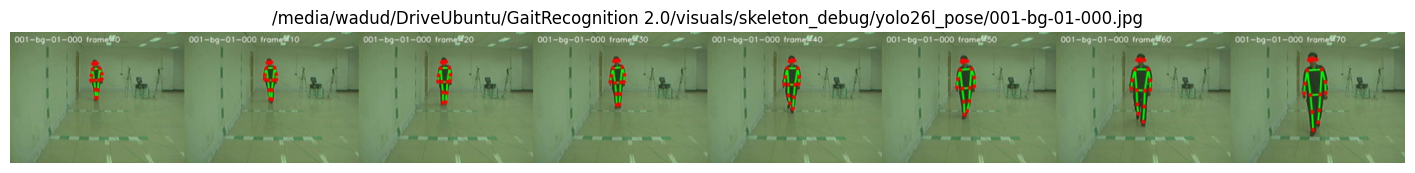

In [9]:
# ============================================================
# CELL 9 — Display one debug skeleton image
# ============================================================

debug_images = sorted(VIS_DIR.glob("*.jpg"))

print("Debug images found:", len(debug_images))

if len(debug_images) > 0:
    img_path = debug_images[0]
    img = cv2.imread(str(img_path))

    if img is None:
        print("Could not read debug image:", img_path)
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(18, 6))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(str(img_path))
        plt.show()
else:
    print("No debug image found. Check the previous cell.")

In [10]:
# ============================================================
# CELL 10 — Run full skeleton extraction
# ============================================================

summary_rows = []
failed_rows = []

if RUN_FULL_EXTRACTION:
    start_time = time.time()

    for idx, rec in enumerate(tqdm(records, desc="Extracting all CASIA-B skeletons")):
        save_vis = idx < SAVE_DEBUG_VIS_N

        try:
            row = process_one_video(rec, save_vis=save_vis)
            summary_rows.append(row)

        except Exception as e:
            error_text = traceback.format_exc()

            row = {
                "status": "failed",
                "video_path": rec["video_path"],
                "out_npz": str(output_npz_path_for_record(rec)),
                "subject": rec["subject"],
                "condition": rec["condition"],
                "seq": rec["seq"],
                "view": rec["view"],
                "fps": "",
                "width": "",
                "height": "",
                "frame_count_cv2": "",
                "frame_count_processed": "",
                "valid_frame_ratio": "",
                "mean_kpt_score": "",
                "mean_det_score": "",
                "error": str(e),
            }

            summary_rows.append(row)
            failed_rows.append({
                "video_path": rec["video_path"],
                "error": error_text,
            })

        if len(summary_rows) % 100 == 0:
            pd.DataFrame(summary_rows).to_csv(
                REPORT_DIR / "skeleton_extraction_summary_partial.csv",
                index=False
            )

    elapsed = time.time() - start_time

    df_summary = pd.DataFrame(summary_rows)
    df_failed = pd.DataFrame(failed_rows)

    summary_csv = REPORT_DIR / "skeleton_extraction_summary.csv"
    failed_csv = REPORT_DIR / "failed_videos.csv"

    df_summary.to_csv(summary_csv, index=False)
    df_failed.to_csv(failed_csv, index=False)

    print("=" * 80)
    print("FULL EXTRACTION DONE")
    print("=" * 80)
    print("Elapsed minutes:", elapsed / 60)
    print("Summary saved  :", summary_csv)
    print("Failed saved   :", failed_csv)
    print("Pose root      :", POSE_ROOT)
    print("=" * 80)

    display(df_summary["status"].value_counts())

else:
    print("RUN_FULL_EXTRACTION is False, so full extraction was skipped.")
    print("Set RUN_FULL_EXTRACTION = True in Cell 2 to process all videos.")

Extracting all CASIA-B skeletons:   0%|          | 0/13640 [00:00<?, ?it/s]

FULL EXTRACTION DONE
Elapsed minutes: 379.55247460603715
Summary saved  : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/skeleton_extraction_summary.csv
Failed saved   : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/failed_videos.csv
Pose root      : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose


status
ok                13635
skipped_exists        5
Name: count, dtype: int64

In [11]:
# ============================================================
# CELL 11 — Verify output files and pose quality
# ============================================================

pose_files = sorted(POSE_ROOT.rglob("*.npz"))

print("Total pose .npz files:", len(pose_files))
print("Expected full CASIA-B :", 124 * 10 * 11)
print("Pose root             :", POSE_ROOT)

summary_csv = REPORT_DIR / "skeleton_extraction_summary.csv"

if summary_csv.exists():
    df_summary = pd.read_csv(summary_csv)
    print("\nStatus counts:")
    display(df_summary["status"].value_counts())

    ok_df = df_summary[df_summary["status"] == "ok"].copy()

    if len(ok_df) > 0:
        print("\nQuality summary:")
        display(ok_df[[
            "frame_count_processed",
            "valid_frame_ratio",
            "mean_kpt_score",
            "mean_det_score"
        ]].describe())

        low_quality = ok_df[
            (ok_df["valid_frame_ratio"] < 0.70) |
            (ok_df["mean_kpt_score"] < 0.30)
        ]

        print("Low-quality videos:", len(low_quality))
        display(low_quality.head(20))
else:
    print("No full summary CSV found yet:", summary_csv)

Total pose .npz files: 13640
Expected full CASIA-B : 13640
Pose root             : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose

Status counts:


status
ok                13635
skipped_exists        5
Name: count, dtype: int64


Quality summary:


,frame_count_processed,valid_frame_ratio,mean_kpt_score,mean_det_score
count,13635.000000,13635.000000,13635.000000,13635.000000
mean,120.980785,0.797222,0.653434,0.684385
std,21.730100,0.151628,0.168085,0.120894
min,12.000000,0.000000,0.000000,0.000000
25%,106.000000,0.672000,0.509304,0.592035
50%,120.000000,0.800000,0.629638,0.680263
75%,134.000000,0.937500,0.781417,0.784025
max,311.000000,1.000000,0.970498,0.941476


Low-quality videos: 4217


,status,video_path,out_npz,subject,condition,seq,view,fps,width,height,frame_count_cv2,frame_count_processed,valid_frame_ratio,mean_kpt_score,mean_det_score,error
5,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,1,90,25.0,320.0,240.0,106.0,106.0,0.669811,0.488305,0.620368,NaN
15,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,2,72,25.0,320.0,240.0,116.0,116.0,0.637931,0.498538,0.616666,NaN
16,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,2,90,25.0,320.0,240.0,114.0,114.0,0.622807,0.453924,0.582406,NaN
17,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,2,108,25.0,320.0,240.0,116.0,116.0,0.646552,0.466491,0.584814,NaN
18,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,2,126,25.0,320.0,240.0,113.0,113.0,0.672566,0.492222,0.602867,NaN
27,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,cl,1,90,25.0,320.0,240.0,100.0,100.0,0.630000,0.468159,0.582998,NaN
28,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,cl,1,108,25.0,320.0,240.0,98.0,98.0,0.642857,0.470553,0.600133,NaN
29,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,cl,1,126,25.0,320.0,240.0,98.0,98.0,0.663265,0.488924,0.618737,NaN
30,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,cl,1,144,25.0,320.0,240.0,102.0,102.0,0.656863,0.484381,0.604248,NaN
48,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,nm,1,72,25.0,320.0,240.0,101.0,101.0,0.693069,0.553531,0.653589,NaN


In [12]:
# ============================================================
# CELL 12 — Inspect one saved .npz file
# ============================================================

pose_files = sorted(POSE_ROOT.rglob("*.npz"))

if len(pose_files) == 0:
    print("No .npz files found yet.")
else:
    sample_pose_file = pose_files[0]
    data = np.load(sample_pose_file)

    print("Sample pose file:", sample_pose_file)
    print("Available keys:")
    print(data.files)

    print()
    print("keypoints shape              :", data["keypoints"].shape)
    print("keypoints_filled shape       :", data["keypoints_filled"].shape)
    print("keypoints_norm shape         :", data["keypoints_norm"].shape)
    print("keypoints_norm_filled shape  :", data["keypoints_norm_filled"].shape)
    print("scores shape                 :", data["scores"].shape)
    print("frame_valid shape            :", data["frame_valid"].shape)
    print()
    print("Use this for GaitTR training: data['keypoints_norm_filled']")

Sample pose file: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose/001/bg-01/000.npz
Available keys:
['keypoints', 'keypoints_filled', 'keypoints_norm', 'keypoints_norm_filled', 'scores', 'bboxes', 'det_scores', 'frame_valid', 'subject', 'condition', 'seq', 'view', 'video_path', 'filename', 'pose_model', 'fps', 'width', 'height', 'frame_count_cv2', 'frame_count_processed', 'kp_conf_thr', 'min_valid_joints']

keypoints shape              : (99, 17, 2)
keypoints_filled shape       : (99, 17, 2)
keypoints_norm shape         : (99, 17, 2)
keypoints_norm_filled shape  : (99, 17, 2)
scores shape                 : (99, 17)
frame_valid shape            : (99,)

Use this for GaitTR training: data['keypoints_norm_filled']


In [13]:
# ============================================================
# CELL 13 — GaitTR feature builder: (T,17,2) -> (10,T,17)
# ============================================================

COCO_PARENTS = np.array([
    0,   # 0 nose
    0,   # 1 left_eye      <- nose
    0,   # 2 right_eye     <- nose
    1,   # 3 left_ear      <- left_eye
    2,   # 4 right_ear     <- right_eye
    0,   # 5 left_shoulder <- nose
    0,   # 6 right_shoulder<- nose
    5,   # 7 left_elbow    <- left_shoulder
    6,   # 8 right_elbow   <- right_shoulder
    7,   # 9 left_wrist    <- left_elbow
    8,   # 10 right_wrist  <- right_elbow
    5,   # 11 left_hip     <- left_shoulder
    6,   # 12 right_hip    <- right_shoulder
    11,  # 13 left_knee    <- left_hip
    12,  # 14 right_knee   <- right_hip
    13,  # 15 left_ankle   <- left_knee
    14,  # 16 right_ankle  <- right_knee
], dtype=np.int64)


def build_gaittr_features(X):
    """
    Build 10-channel GaitTR input features.

    Args:
        X: normalized skeleton sequence, shape (T, 17, 2)

    Returns:
        feat: shape (10, T, 17)
    """

    X = X.astype(np.float32)

    assert X.ndim == 3, f"Expected (T, 17, 2), got {X.shape}"
    assert X.shape[1] == 17, f"Expected 17 joints, got {X.shape[1]}"
    assert X.shape[2] == 2, f"Expected x,y coordinates, got {X.shape[2]}"

    joint = X.copy()

    nose = X[:, 0:1, :]
    joint_rel = X - nose

    v1 = np.zeros_like(X)
    v1[:-1] = X[1:] - X[:-1]

    v2 = np.zeros_like(X)
    v2[:-2] = X[2:] - X[:-2]

    bone = X - X[:, COCO_PARENTS, :]

    feat = np.concatenate([joint, joint_rel, v1, v2, bone], axis=-1)
    feat = feat.transpose(2, 0, 1).astype(np.float32)

    return feat


def crop_or_pad_sequence(X, seq_len=60, random_crop=False):
    """
    X: (T,17,2)
    Returns: (seq_len,17,2)
    """

    T = X.shape[0]

    if T == seq_len:
        return X

    if T > seq_len:
        if random_crop:
            start = np.random.randint(0, T - seq_len + 1)
        else:
            start = max(0, (T - seq_len) // 2)
        return X[start:start + seq_len]

    pad_len = seq_len - T
    pad = np.repeat(X[-1:], pad_len, axis=0)
    return np.concatenate([X, pad], axis=0)


pose_files = sorted(POSE_ROOT.rglob("*.npz"))

if len(pose_files) > 0:
    sample_pose_file = pose_files[0]
    data = np.load(sample_pose_file)
    X = data["keypoints_norm_filled"]
    X60 = crop_or_pad_sequence(X, seq_len=60, random_crop=False)
    feat = build_gaittr_features(X60)

    print("Sample pose file       :", sample_pose_file)
    print("Original skeleton shape:", X.shape)
    print("Cropped skeleton shape :", X60.shape)
    print("GaitTR feature shape   :", feat.shape)

    assert feat.shape == (10, 60, 17)
    print("[OK] Feature builder works.")
else:
    print("No pose file found; run extraction cells first.")

Sample pose file       : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose/001/bg-01/000.npz
Original skeleton shape: (99, 17, 2)
Cropped skeleton shape : (60, 17, 2)
GaitTR feature shape   : (10, 60, 17)
[OK] Feature builder works.


In [14]:
# ============================================================
# CELL 14 — Create LT train/test/gallery/probe split files
# ============================================================

train_subjects_LT = [f"{i:03d}" for i in range(1, 75)]
test_subjects_LT = [f"{i:03d}" for i in range(75, 125)]

with open(SPLIT_DIR / "train_LT_subjects.txt", "w") as f:
    for s in train_subjects_LT:
        f.write(s + "\n")

with open(SPLIT_DIR / "test_LT_subjects.txt", "w") as f:
    for s in test_subjects_LT:
        f.write(s + "\n")


def make_pose_record_from_npz(npz_path: Path):
    rel = npz_path.relative_to(POSE_ROOT)
    subject = rel.parts[0]
    condition_seq = rel.parts[1]
    view = npz_path.stem

    condition, seq = condition_seq.split("-")

    return {
        "pose_path": str(npz_path),
        "subject": subject,
        "condition": condition,
        "seq": seq,
        "view": view,
    }


all_pose_records = [
    make_pose_record_from_npz(p)
    for p in sorted(POSE_ROOT.rglob("*.npz"))
]

df_pose = pd.DataFrame(all_pose_records)

if len(df_pose) == 0:
    print("No pose files found, so gallery/probe CSV files were not created.")
else:
    test_set = set(test_subjects_LT)
    df_test = df_pose[df_pose["subject"].isin(test_set)].copy()

    df_gallery = df_test[
        (df_test["condition"] == "nm") &
        (df_test["seq"].isin(["01", "02", "03", "04"]))
    ].copy()

    df_probe_nm = df_test[
        (df_test["condition"] == "nm") &
        (df_test["seq"].isin(["05", "06"]))
    ].copy()

    df_probe_bg = df_test[
        (df_test["condition"] == "bg") &
        (df_test["seq"].isin(["01", "02"]))
    ].copy()

    df_probe_cl = df_test[
        (df_test["condition"] == "cl") &
        (df_test["seq"].isin(["01", "02"]))
    ].copy()

    df_gallery.to_csv(SPLIT_DIR / "gallery_LT.csv", index=False)
    df_probe_nm.to_csv(SPLIT_DIR / "probe_LT_nm.csv", index=False)
    df_probe_bg.to_csv(SPLIT_DIR / "probe_LT_bg.csv", index=False)
    df_probe_cl.to_csv(SPLIT_DIR / "probe_LT_cl.csv", index=False)

    print("Train LT subjects:", train_subjects_LT[0], "to", train_subjects_LT[-1], len(train_subjects_LT))
    print("Test LT subjects :", test_subjects_LT[0], "to", test_subjects_LT[-1], len(test_subjects_LT))
    print()
    print("Gallery LT :", len(df_gallery), "expected if full extraction: 50*4*11 = 2200")
    print("Probe LT NM:", len(df_probe_nm), "expected if full extraction: 50*2*11 = 1100")
    print("Probe LT BG:", len(df_probe_bg), "expected if full extraction: 50*2*11 = 1100")
    print("Probe LT CL:", len(df_probe_cl), "expected if full extraction: 50*2*11 = 1100")
    print()
    print("Saved split files to:", SPLIT_DIR)

    display(df_gallery.head())

Train LT subjects: 001 to 074 74
Test LT subjects : 075 to 124 50

Gallery LT : 2200 expected if full extraction: 50*4*11 = 2200
Probe LT NM: 1100 expected if full extraction: 50*2*11 = 1100
Probe LT BG: 1100 expected if full extraction: 50*2*11 = 1100
Probe LT CL: 1100 expected if full extraction: 50*2*11 = 1100

Saved split files to: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/splits


,pose_path,subject,condition,seq,view
8184,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,000
8185,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,018
8186,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,036
8187,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,054
8188,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,072


## Next step after this notebook

Your GaitTR training notebook should load pose files like this:

```python
data = np.load(pose_path)
X = data["keypoints_norm_filled"]     # shape: (T, 17, 2)
X = crop_or_pad_sequence(X, 60, random_crop=True)
feat = build_gaittr_features(X)       # shape: (10, 60, 17)
```

The final training tensor shape should be:

```text
B × 10 × 60 × 17
```